# E-Commerce Sales Data Analysis Using Python

An Exploratory Data Analysis (EDA) project using Pandas, NumPy, Matplotlib and Seaborn.

## Objective
Analyze e-commerce sales data, clean the dataset, identify trends, compare categories/regions, and generate useful visualizations.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("ecommerce_sales.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(df.head())
print("Shape:", df.shape)

                           Date Customer_ID            Product  Category  \
0 2025-01-01 00:00:00.000000000    CUST1083        Python Book     Books   
1 2025-01-02 05:13:02.608695652    CUST1003            Cushion      Home   
2 2025-01-03 10:26:05.217391304    CUST1021              Shoes  Clothing   
3 2025-01-04 15:39:07.826086956    CUST1059            AI Book     Books   
4 2025-01-05 20:52:10.434782608    CUST1064  Data Science Book     Books   

      Region  Quantity  Unit_Price  Sales   Profit  
0    Chennai         3      3972.0  11916  3441.94  
1      Delhi         5      3371.0  16855  6934.58  
2  Hyderabad         4      2633.0  10532  4222.36  
3  Bengaluru         5      3104.0  15520  5763.63  
4  Hyderabad         3      2099.0   6297  1959.35  
Shape: (303, 9)


## 1. Understand the Dataset

In [2]:
print(df.info())
print("\nColumns:", df.columns.tolist())
print("\nStatistics:")
display(df.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         303 non-null    datetime64[ns]
 1   Customer_ID  303 non-null    str           
 2   Product      303 non-null    str           
 3   Category     303 non-null    str           
 4   Region       302 non-null    str           
 5   Quantity     303 non-null    int64         
 6   Unit_Price   302 non-null    float64       
 7   Sales        303 non-null    int64         
 8   Profit       303 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), str(4)
memory usage: 30.4 KB
None

Columns: ['Date', 'Customer_ID', 'Product', 'Category', 'Region', 'Quantity', 'Unit_Price', 'Sales', 'Profit']

Statistics:


,Date,Customer_ID,Product,Category,Region,Quantity,Unit_Price,Sales,Profit
count,303,303,303,303,302,303.00000,302.000000,303.000000,303.000000
unique,NaN,95,20,5,5,NaN,NaN,NaN,NaN
top,NaN,CUST1003,Python Book,Books,Hyderabad,NaN,NaN,NaN,NaN
freq,NaN,7,25,65,64,NaN,NaN,NaN,NaN
mean,2025-06-30 05:02:30.322858240,NaN,NaN,NaN,NaN,3.00330,2540.420530,7634.155116,2416.563663
min,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,1.00000,203.000000,578.000000,152.500000
25%,2025-03-30 06:15:39.130434816,NaN,NaN,NaN,NaN,2.00000,1333.000000,3127.000000,929.095000
50%,2025-06-30 04:10:26.086956544,NaN,NaN,NaN,NaN,3.00000,2415.500000,6012.000000,1851.270000
75%,2025-09-30 02:05:13.043478272,NaN,NaN,NaN,NaN,4.00000,3648.250000,11151.000000,3407.725000
max,2025-12-31 00:00:00,NaN,NaN,NaN,NaN,5.00000,4998.000000,24990.000000,10592.060000


## 2. Data Cleaning

In [3]:
print("Missing values before cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])
df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nShape after cleaning:", df.shape)

Missing values before cleaning:
Date           0
Customer_ID    0
Product        0
Category       0
Region         1
Quantity       0
Unit_Price     1
Sales          0
Profit         0
dtype: int64

Duplicate rows: 3

Missing values after cleaning:
Date           0
Customer_ID    0
Product        0
Category       0
Region         0
Quantity       0
Unit_Price     0
Sales          0
Profit         0
dtype: int64

Shape after cleaning: (300, 9)


## 3. Key Business Metrics

In [4]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()

print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")

Total Sales: ₹2,273,846.00
Total Profit: ₹717,619.91
Total Quantity Sold: 898


## 4. Sales by Category

Category
Books          537966
Sports         481242
Home           456701
Electronics    432239
Clothing       365698
Name: Sales, dtype: int64

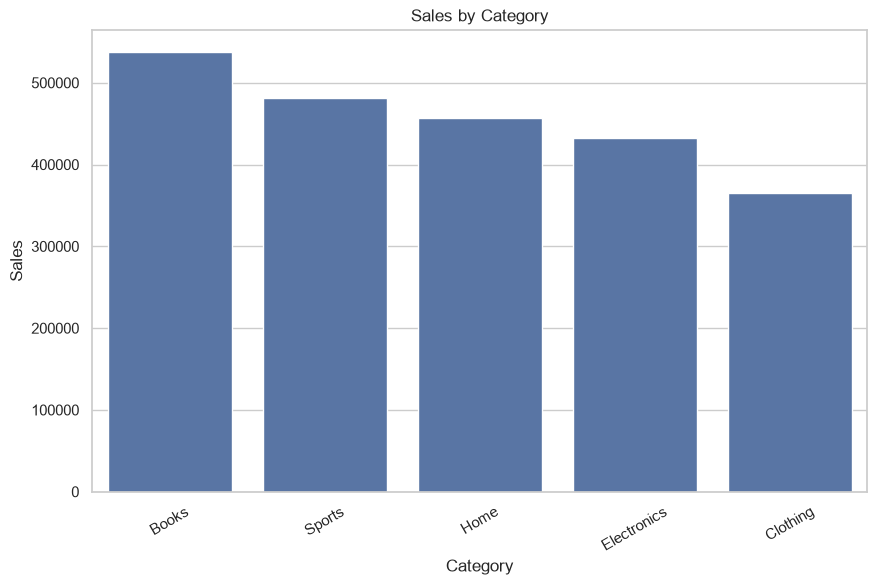

In [5]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
display(category_sales)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.show()

## 5. Sales by Region

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
display(region_sales)

plt.figure(figsize=(10,6))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.show()

## 6. Monthly Sales Trend

In [ ]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Top 10 Products

In [ ]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)
display(top_products)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

## 8. Sales Distribution

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

## 9. Correlation Heatmap

In [ ]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 10. Key Findings

- Compare the highest-selling category and region.
- Identify the top products by sales.
- Observe monthly sales patterns.
- Check the relationship between quantity, unit price, sales and profit.

## Conclusion
This project demonstrates the complete EDA workflow: data loading, data understanding, cleaning, statistical analysis, visualization and business insights.